In [1]:
# Автоматично підхоплює зміни в src/*.py без перезапуску ядра.
%load_ext autoreload
%autoreload 2

In [2]:
import csv
import json
import os
import random
import time
from os import listdir
from os.path import isdir, join
from pathlib import Path

import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import random_split, DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, RandomHorizontalFlip, RandomCrop

from src.dataset import define_transformations
from src.experiment import save_model, save_results, save_config, prepare_results_dir
from src.metrics import plot_training_metrics
from src.training import training_loop


Using device: MPS (Apple Silicon GPU)


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [4]:
with open("../configs/base_config.json", encoding="utf-8") as file:
    config_json = json.load(file)

seed = int(config_json["seed"])

batch_size = int(config_json["data"]["batch_size"])
augmentation = config_json["data"]["augmentation"]

model = config_json["model"]["name"]
dropout = config_json["model"]["dropout"]

learning_rate = float(config_json["training"]["learning_rate"])
weight_decay = float(config_json["training"]["weight_decay"])
scheduler_config = config_json["training"]["scheduler"]
epochs = int(config_json["training"]["epochs"])

early_stopping_config = config_json["training"]["early_stopping"]
early_stopping_patience = int(early_stopping_config["patience"])
early_stopping_min_delta = float(early_stopping_config["min_delta"])

In [5]:
random.seed(seed)
torch.manual_seed(seed)

In [6]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [7]:
train_transform, val_transform = define_transformations(augmentation, IMAGENET_MEAN, IMAGENET_STD)

In [8]:
# Load training split for 37-class pet breed classification.
# train_dataset and val_dataset are two SEPARATE OxfordIIITPet instances (not
# one dataset split via random_split alone) so train/val get different
# transforms - a Subset of a single dataset would inherit that dataset's
# transform for both, silently running the random train-time augmentation on
# validation images too.
train_dataset = OxfordIIITPet(
    root="../data",
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)
val_dataset = OxfordIIITPet(
    root="../data",
    split="trainval",
    target_types="category",
    download=True,
    transform=val_transform
)
test_dataset = OxfordIIITPet(
    root="../data",
    split="test",
    target_types="category",
    download=True,
    transform=val_transform
)

In [9]:
generator = torch.Generator().manual_seed(seed)
train_indices, val_indices = random_split(train_dataset, [0.7, 0.3], generator=generator)

train_loader = DataLoader(Subset(train_dataset, train_indices.indices), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(Subset(val_dataset, val_indices.indices), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
class MyAlexNet(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 96, 11, stride=4, padding=1)
        self.batchNorm1 = nn.BatchNorm2d(96)
        self.pool1 = nn.MaxPool2d(3, 2)

        self.conv2 = nn.Conv2d(96, 256, 5, stride=1, padding=2)
        self.batchNorm2 = nn.BatchNorm2d(256)
        self.pool2 = nn.MaxPool2d(3, 2)

        self.conv3 = nn.Conv2d(256, 384, 3, stride=1, padding=1)
        self.batchNorm3 = nn.BatchNorm2d(384)
        self.conv4 = nn.Conv2d(384, 384, 3, stride=1, padding=1)
        self.batchNorm4 = nn.BatchNorm2d(384)
        self.conv5 = nn.Conv2d(384, 256, 3, stride=1, padding=1)
        self.batchNorm5 = nn.BatchNorm2d(256)

        self.pool3 = nn.MaxPool2d(3, 2)

        self.relu = nn.ReLU()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6400, 4096),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.relu(self.batchNorm1(self.conv1(x)))
        x = self.pool1(x)

        x = self.relu(self.batchNorm2(self.conv2(x)))
        x = self.pool2(x)

        x = self.relu(self.batchNorm3(self.conv3(x)))
        x = self.relu(self.batchNorm4(self.conv4(x)))
        x = self.relu(self.batchNorm5(self.conv5(x)))

        x = self.pool3(x)

        x = self.classifier(x)

        return x

In [11]:
num_classes = len(train_dataset.classes)
print(f"{num_classes} classes found.")

37 classes found.


In [12]:
verify_simple_cnn = MyAlexNet(num_classes=10, dropout=0.5)
print("Model Structure:\n")
print(verify_simple_cnn)

Model Structure:

MyAlexNet(
  (conv1): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(1, 1))
  (batchNorm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (batchNorm2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchNorm3): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchNorm4): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv5): Conv2d(384, 256, kernel_size=(3, 3), stride

In [13]:
# Create a dummy input tensor (batch_size=64, channels=3, height=32, width=32)
dummy_input = torch.randn(64, 3, 224, 224)
print(f"\nInput tensor shape:  {dummy_input.shape}")
# Pass the dummy tensor through the model
output = verify_simple_cnn(dummy_input)
print(f"Output tensor shape: {output.shape}")


Input tensor shape:  torch.Size([64, 3, 224, 224])
Output tensor shape: torch.Size([64, 10])


In [14]:
model = MyAlexNet(num_classes=num_classes, dropout=dropout)

In [15]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode=scheduler_config["mode"],
    factor=float(scheduler_config["factor"]),
    patience=int(scheduler_config["patience"]),
    min_lr=float(scheduler_config["min_lr"]),
)

In [16]:
results_dir, exp_number, exp_path = prepare_results_dir("../experiments")
print("Results Directory:", results_dir)
print("Experiment Number:", exp_number)
print("Experiment Path:", exp_path)

Results Directory: ../experiments
Experiment Number: 49
Experiment Path: ../experiments/49


In [17]:
save_config(exp_path, config_json)

In [18]:
trained_model, training_metrics = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=epochs,
    device=device,
    scheduler=scheduler,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta
)

--- Training Started ---
Epoch [1/50], Train Loss: 3.9900, Train Accuracy: 3.03% Val Loss: 3.5991, Val Accuracy: 3.44%
Epoch [2/50], Train Loss: 3.5812, Train Accuracy: 3.26% Val Loss: 3.5628, Val Accuracy: 4.44%
Epoch [3/50], Train Loss: 3.5541, Train Accuracy: 4.19% Val Loss: 3.5440, Val Accuracy: 4.17%
Epoch [4/50], Train Loss: 3.5196, Train Accuracy: 4.89% Val Loss: 3.5289, Val Accuracy: 6.16%
Epoch [5/50], Train Loss: 3.5155, Train Accuracy: 5.43% Val Loss: 3.4664, Val Accuracy: 5.62%
Epoch [6/50], Train Loss: 3.5076, Train Accuracy: 6.02% Val Loss: 3.4841, Val Accuracy: 5.80%
Epoch [7/50], Train Loss: 3.4709, Train Accuracy: 6.33% Val Loss: 3.4278, Val Accuracy: 6.97%
Epoch [8/50], Train Loss: 3.4589, Train Accuracy: 6.44% Val Loss: 3.4328, Val Accuracy: 7.25%
Epoch [9/50], Train Loss: 3.4615, Train Accuracy: 6.48% Val Loss: 3.4791, Val Accuracy: 5.71%
Epoch [10/50], Train Loss: 3.4402, Train Accuracy: 7.34% Val Loss: 3.4167, Val Accuracy: 7.70%
Epoch [11/50], Train Loss: 3.4368,


--- Training Plots ---



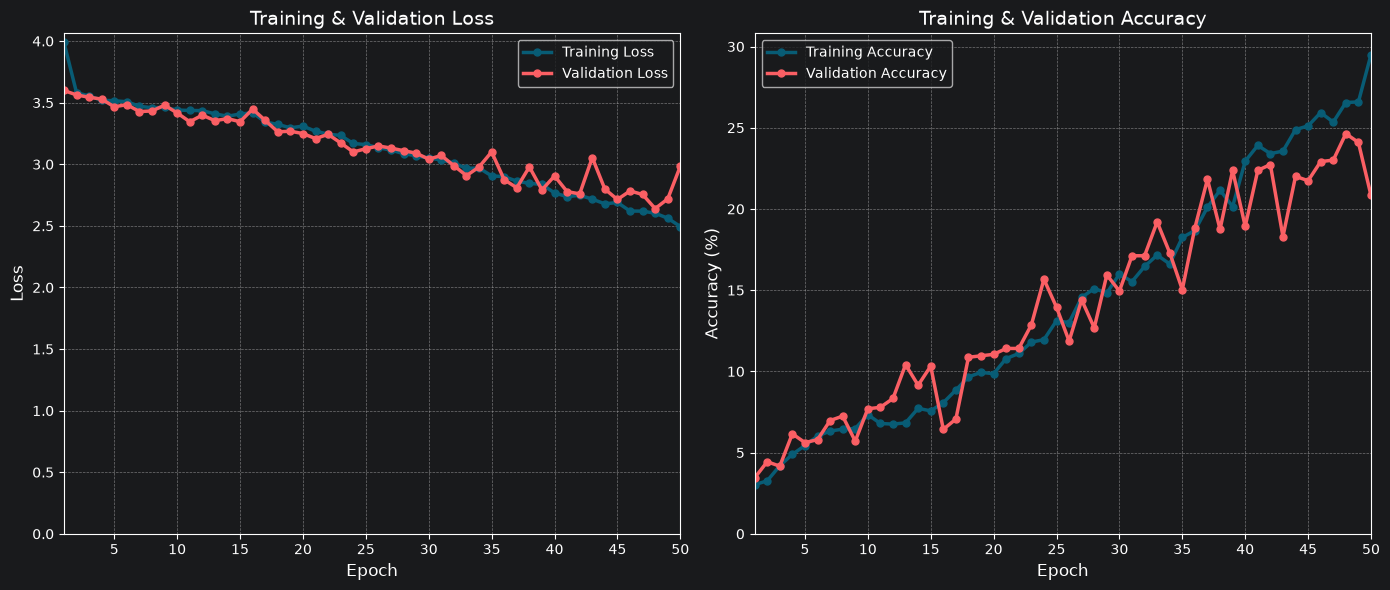

In [19]:
print("\n--- Training Plots ---\n")
plot_training_metrics(training_metrics, exp_path)

In [20]:
save_results(results_dir,
             exp_path,
             exp_number,
             learning_rate,
             training_metrics,
             model.__class__.__name__,
             len(training_metrics[0]),
             batch_size,
             optimizer.__class__.__name__,
             weight_decay,
             seed,
             str(augmentation),
             dropout,
             scheduler_config
             )

In [21]:
save_model(exp_path, model)